In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
import os
np.random.seed(42)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
datosMLP = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/24paso/consumption/24pasos_mlp_consumption.csv')

datosMLP['date'] = pd.to_datetime(datosMLP['Unnamed: 0'])
datosMLP = datosMLP.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 11
datosMLP = datosMLP.iloc[corte:]

# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)

datosMLP.head()

,Originales,Predichos
date,,
2017-11-25 01:30:00,-1.353240,-0.132079
2017-11-25 01:40:00,-1.345607,-0.238311
2017-11-25 01:50:00,-1.349847,-0.344108
2017-11-25 02:00:00,-1.400737,-0.375692
2017-11-25 02:10:00,-1.449082,-0.435025


In [4]:
datosLSTM = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/24paso/consumption/24pasos_lstm_consumption.csv')

datosLSTM['date'] = pd.to_datetime(datosLSTM['Unnamed: 0'])
datosLSTM = datosLSTM.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 11
datosLSTM = datosLSTM.iloc[corte:]

# Se establece la columna date como index
datosLSTM.set_index('date', inplace=True)

datosLSTM.head()

,Originales,Predichos
date,,
2017-11-25 01:30:00,-1.353240,-1.036799
2017-11-25 01:40:00,-1.345607,-1.078490
2017-11-25 01:50:00,-1.349847,-1.116047
2017-11-25 02:00:00,-1.400737,-1.138026
2017-11-25 02:10:00,-1.449082,-1.152446


In [5]:
datosGRU= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/24paso/consumption/24pasos_gru_consumption.csv')

datosGRU['date'] = pd.to_datetime(datosGRU['Unnamed: 0'])
datosGRU = datosGRU.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 11
datosGRU = datosGRU.iloc[corte:]

# Se establece la columna date como index
datosGRU.set_index('date', inplace=True)

datosGRU.head()

,Originales,Predichos
date,,
2017-11-25 01:30:00,-1.353240,-1.193832
2017-11-25 01:40:00,-1.345607,-1.224127
2017-11-25 01:50:00,-1.349847,-1.261950
2017-11-25 02:00:00,-1.400737,-1.271162
2017-11-25 02:10:00,-1.449082,-1.276833


In [6]:
datosCross= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/24paso/consumption/crossformerConsumption.csv')

datosCross['date'] = pd.to_datetime(datosCross['Unnamed: 0'])
datosCross = datosCross.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross.set_index('date', inplace=True)

datosCross.head()

,Originales,Predichos
date,,
2017-11-25 01:30:00,-1.353240,-0.814439
2017-11-25 01:40:00,-1.345607,-0.834665
2017-11-25 01:50:00,-1.349847,-0.852647
2017-11-25 02:00:00,-1.400737,-0.874528
2017-11-25 02:10:00,-1.449083,-0.896216


In [7]:
datosI= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/24paso/consumption/itransformerConsumption.csv')

datosI['date'] = pd.to_datetime(datosI['Unnamed: 0'])
datosI = datosI.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI.set_index('date', inplace=True)

datosI.head()

,Originales,Predichos
date,,
2017-11-25 01:30:00,-1.353240,-1.158689
2017-11-25 01:40:00,-1.345607,-1.198844
2017-11-25 01:50:00,-1.349847,-1.228719
2017-11-25 02:00:00,-1.400737,-1.233345
2017-11-25 02:10:00,-1.449083,-1.182126


In [8]:
datosTFT= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/24paso/consumption/tftConsumption.csv')

datosTFT['date'] = pd.to_datetime(datosTFT['Unnamed: 0'])
datosTFT = datosTFT.drop(columns=['Unnamed: 0'])

corte = 5347 - 5190 - 20
datosTFT = datosTFT.iloc[corte:]

# Se establece la columna date como index
datosTFT.set_index('date', inplace=True)

datosTFT.head()

,Originales,Predichos
date,,
2017-11-25 01:30:00,-1.353240,-1.287166
2017-11-25 01:40:00,-1.345607,-1.303290
2017-11-25 01:50:00,-1.349847,-1.311201
2017-11-25 02:00:00,-1.400737,-1.316356
2017-11-25 02:10:00,-1.449082,-1.319499


## MLP ##

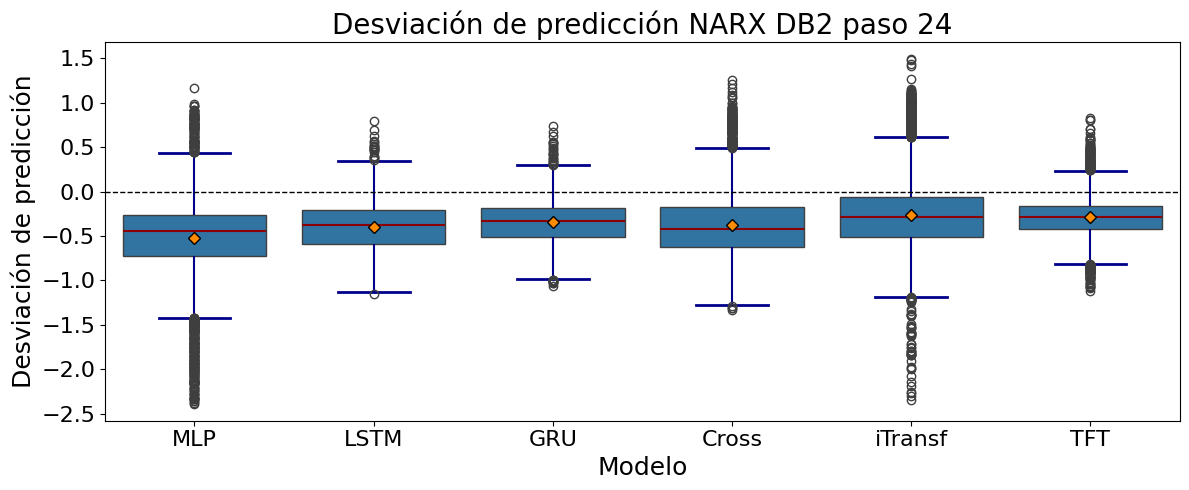

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Función para calcular las desviaciones
def calcular_desviacion(df, nombre_modelo):
    desviacion = df['Originales'] - df['Predichos']
    return pd.DataFrame({'Desviacion': desviacion, 'Modelo': nombre_modelo})

# Lista de modelos y sus datos
dataframes = [datosMLP, datosLSTM, datosGRU, datosCross, datosI, datosTFT]
nombres_modelos = ['MLP', 'LSTM', 'GRU', 'Cross', 'iTransf', 'TFT']

# Calcular todas las desviaciones
todas_las_desviaciones = [calcular_desviacion(df, nombre_modelo) for df, nombre_modelo in zip(dataframes, nombres_modelos)]

# Combinar todos los DataFrames en uno solo
df_grafico = pd.concat(todas_las_desviaciones, ignore_index=True)

# Crear los gráficos de caja
plt.figure(figsize=(12, 5))
sns.boxplot(x='Modelo', y='Desviacion', data=df_grafico, showmeans=True,
            meanprops={"marker":"D", "markerfacecolor":"darkorange", "markeredgecolor":"black"},
            medianprops={"color": "darkred", "linewidth": 1.5},
            whiskerprops=dict(color="darkblue", linewidth=1.5),
            capprops=dict(color="darkblue", linewidth=2))

# Línea horizontal en y=0
plt.axhline(0, linestyle= "--",color='black', linewidth=1.0)


plt.title('Desviación de predicción NARX DB2 paso 24', fontsize=20)
plt.ylabel('Desviación de predicción', fontsize=18)
plt.xlabel('Modelo', fontsize=18)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

#Por la naturaleza del gráfico, no se incluye leyenda

# Ajustar la presentación
plt.tight_layout()
plt.show()


# Graficos Q-Q

In [10]:
rMLP = pd.DataFrame(datosMLP['Originales'] - datosMLP['Predichos'], columns=['MLP'])
rLSTM = pd.DataFrame(datosLSTM['Originales'] - datosLSTM['Predichos'], columns=['LSTM'])
rGRU = pd.DataFrame(datosGRU['Originales'] - datosGRU['Predichos'], columns=['GRU'])
rCross = pd.DataFrame(datosCross['Originales'] - datosCross['Predichos'], columns=['Crossformer'])
rI = pd.DataFrame(datosI['Originales'] - datosI['Predichos'], columns=['iTransformer'])
rTFT = pd.DataFrame(datosTFT['Originales'] - datosTFT['Predichos'], columns=['TFT'])

final = rMLP.join(rLSTM, how='outer').join(rGRU, how='outer').join(rCross, how='outer').join(rI, how='outer').join(rTFT, how='outer')
final.head()





,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2017-11-25 01:30:00,-1.221161,-0.316441,-0.159408,-0.538801,-0.194551,-0.066074
2017-11-25 01:40:00,-1.107295,-0.267117,-0.121480,-0.510942,-0.146762,-0.042317
2017-11-25 01:50:00,-1.005739,-0.233801,-0.087897,-0.497200,-0.121128,-0.038647
2017-11-25 02:00:00,-1.025045,-0.262711,-0.129575,-0.526210,-0.167392,-0.084381
2017-11-25 02:10:00,-1.014057,-0.296637,-0.172249,-0.552866,-0.266956,-0.129584


In [11]:
finalTotal = final.isna().sum()
print(finalTotal)
final = final.dropna()

MLP             0
LSTM            0
GRU             0
Crossformer     0
iTransformer    0
TFT             0
dtype: int64


In [12]:
final = final.sample(frac=0.10, random_state=42)
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2017-12-13 12:10:00,-0.131621,-0.476468,-0.413357,0.032735,-0.429550,-0.258357
2017-12-28 07:40:00,-0.613343,-0.307554,-0.271755,-0.189444,-0.257180,-0.099426
2017-12-15 10:10:00,-0.536274,-0.566183,-0.470438,-0.281244,-0.471497,-0.572966
2017-12-26 20:00:00,-0.349508,-0.687507,-0.469327,-0.861307,-0.563404,-0.442179
2017-12-30 18:30:00,-0.529070,-0.615681,-0.511171,-0.215523,0.442065,-0.332771


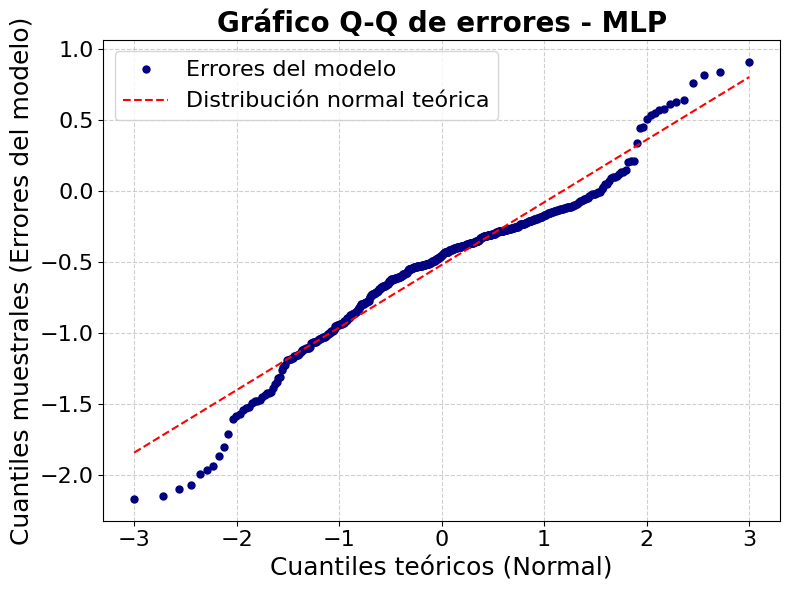

In [13]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["MLP"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - MLP", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


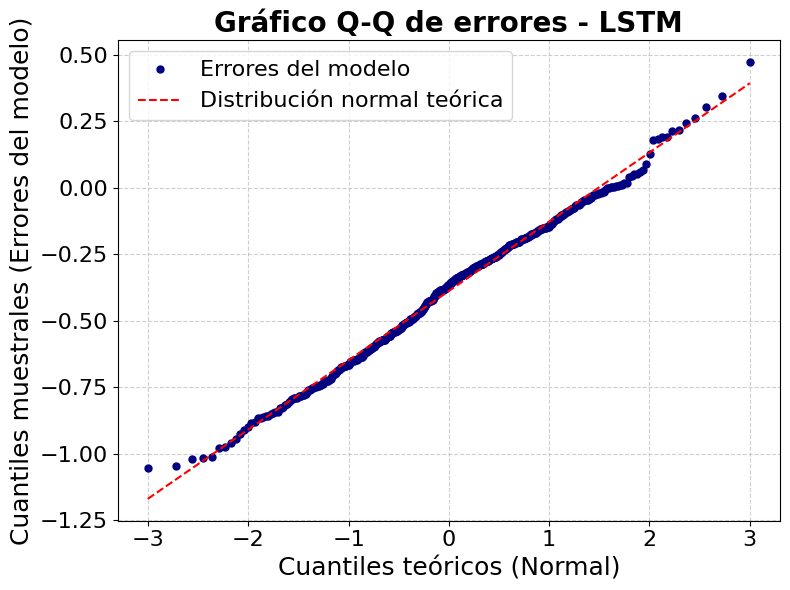

In [14]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["LSTM"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - LSTM", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


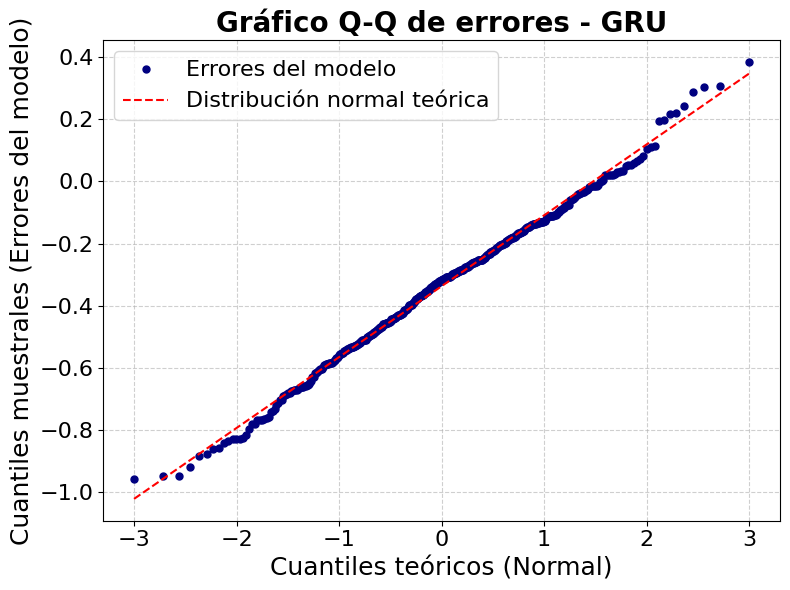

In [15]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["GRU"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - GRU", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


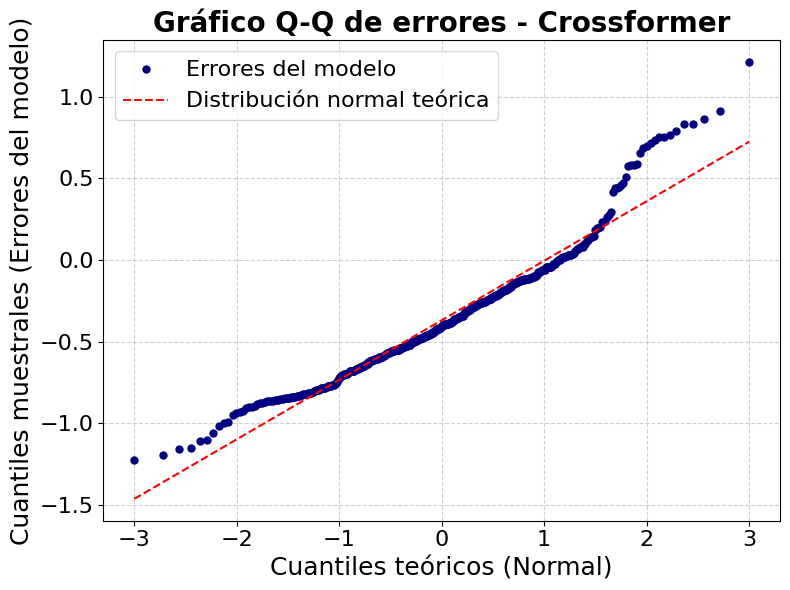

In [16]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["Crossformer"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - Crossformer", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


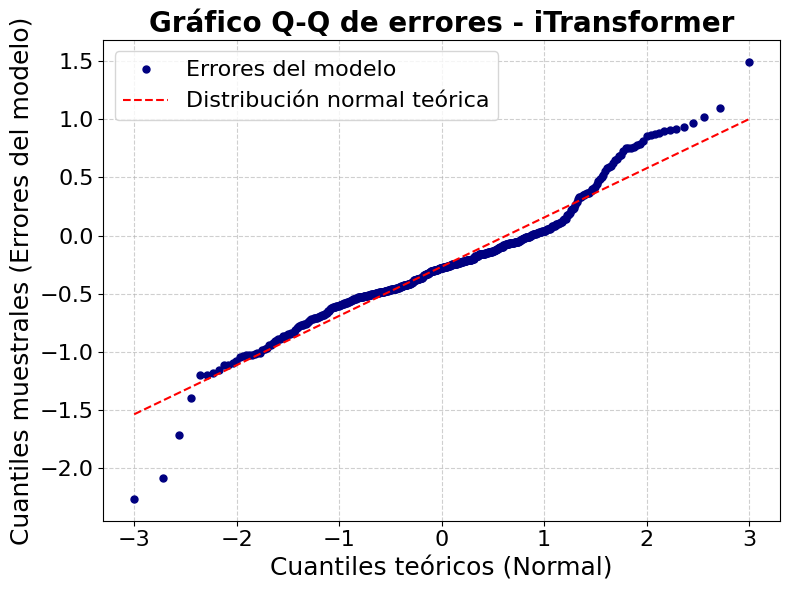

In [17]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["iTransformer"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - iTransformer", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


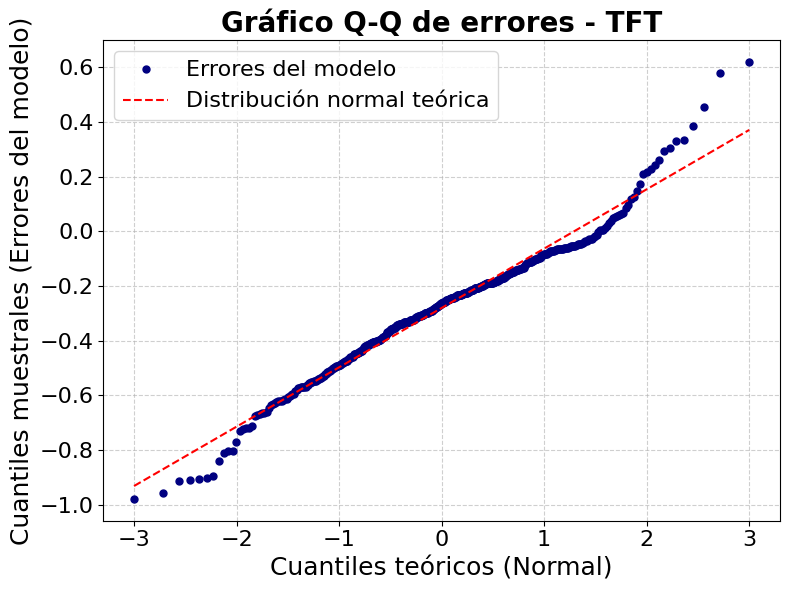

In [18]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["TFT"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - TFT", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


# Predicción

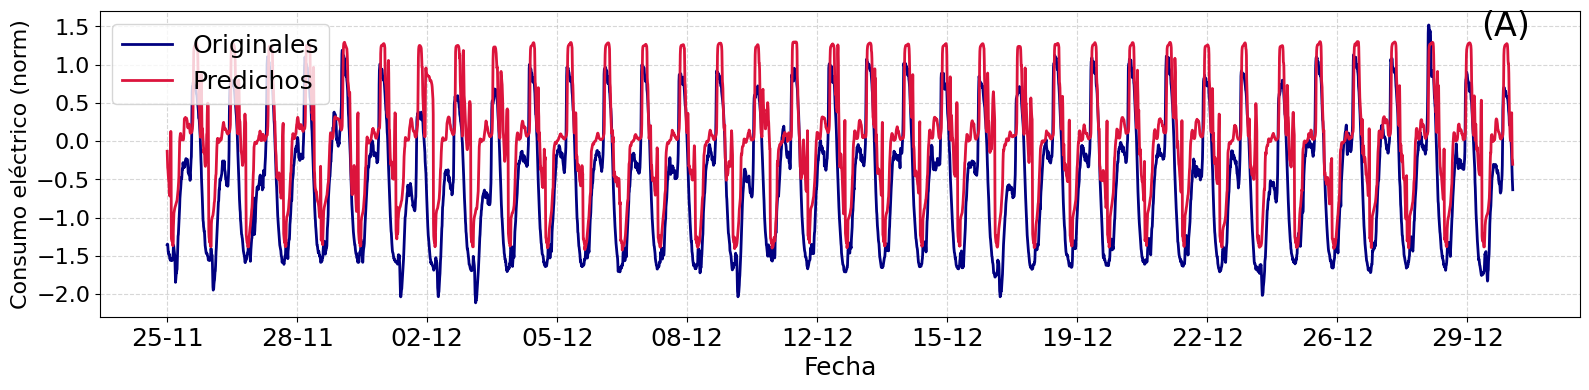

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


plt.figure(figsize=(16, 4))

df = datosMLP
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(A)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()


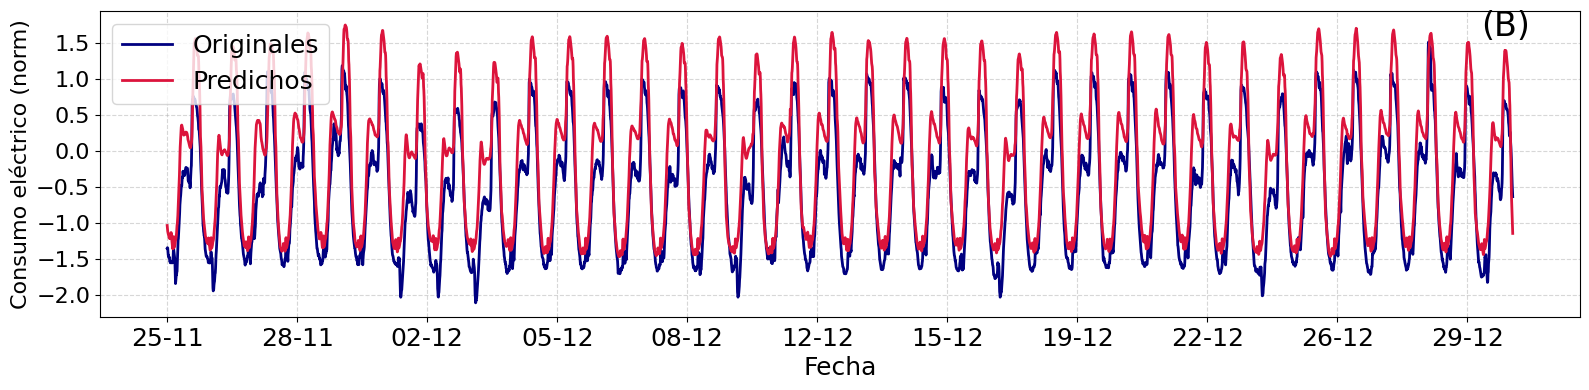

In [20]:

plt.figure(figsize=(16, 4))

df = datosLSTM
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(B)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

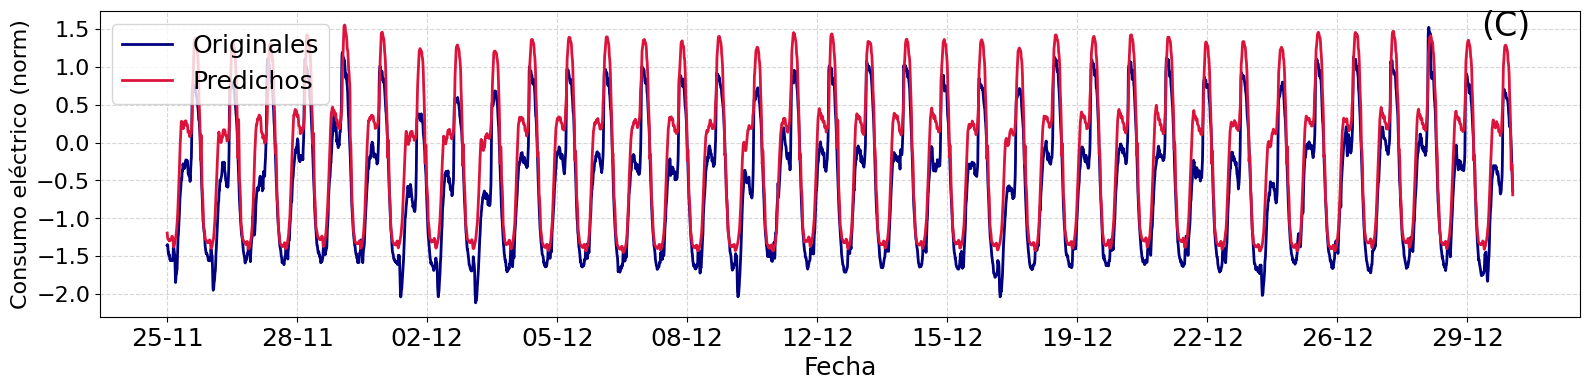

In [21]:

plt.figure(figsize=(16, 4))

df = datosGRU
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(C)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

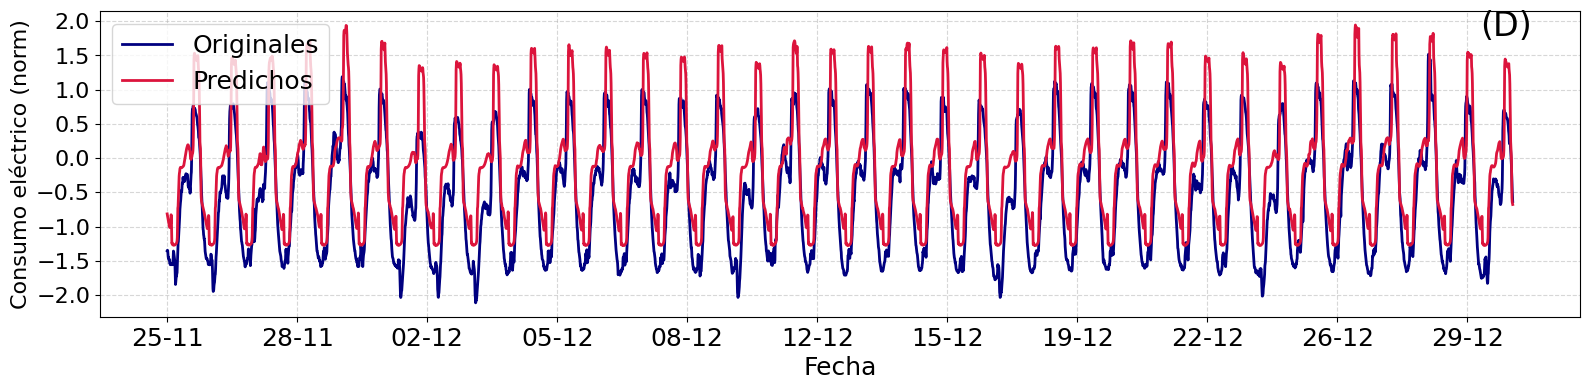

In [22]:

plt.figure(figsize=(16, 4))

df = datosCross
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(D)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

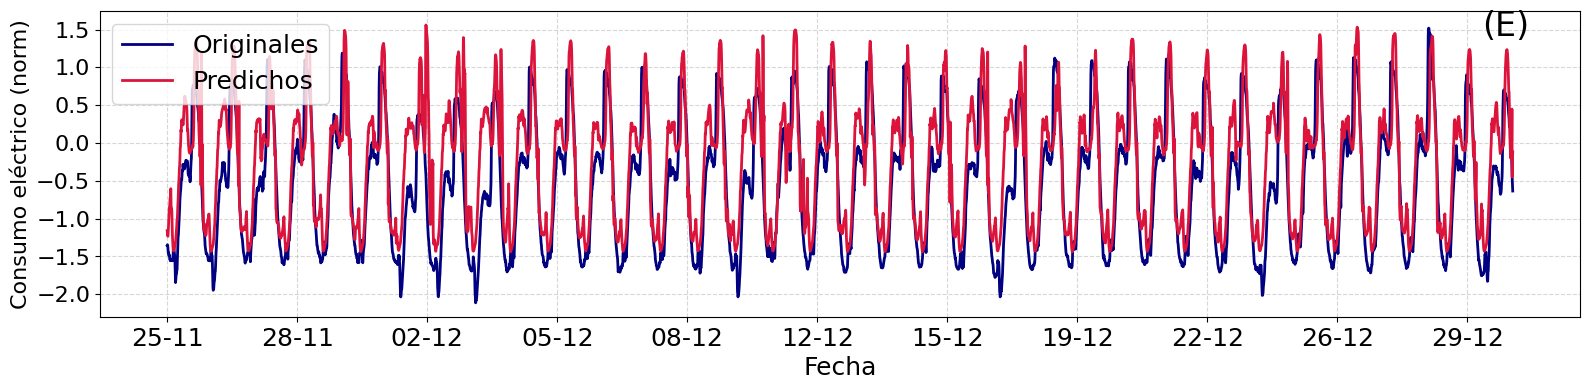

In [23]:

plt.figure(figsize=(16, 4))

df = datosI
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(E)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

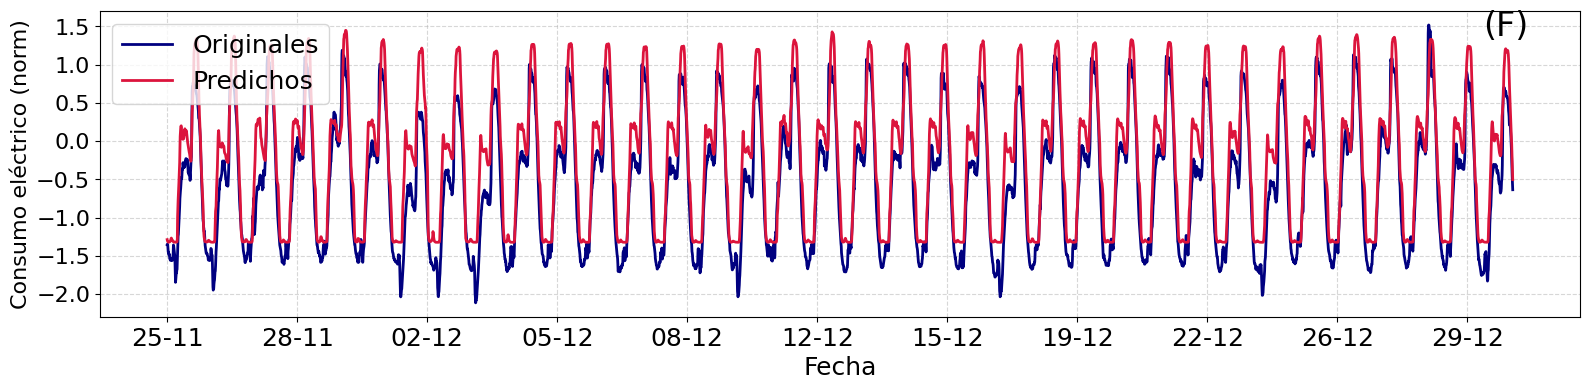

In [24]:

plt.figure(figsize=(16, 4))

df = datosTFT
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(F)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

# Métricas

In [25]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, mean_absolute_error

def smape(y_true, y_pred):
    summ = np.abs(y_true) + np.abs(y_pred)
    smape_val = np.abs(y_pred - y_true) / summ * 2.0
    return np.mean(smape_val)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def ia(y_true, y_pred):
    numerator = np.sum(np.abs(y_true - y_pred))
    denominator = np.sum(np.abs(y_true - np.mean(y_true)) + np.abs(y_pred - np.mean(y_true)))
    return 1 - (numerator / denominator)

In [26]:
#MLP
df = datosMLP

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.4841822316244593
RMSE: 0.6958320426830452
MAE: 0.562905545670884
SMAPE: 1.1646311259958249
IA: 0.6141814108351777


In [27]:
#LSTM
df = datosLSTM

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.22311231652102373
RMSE: 0.47234766488363605
MAE: 0.4076852852110465
SMAPE: 0.8712091898456227
IA: 0.7473721888892827


In [28]:
#GRU
df = datosGRU

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.17571879383181901
RMSE: 0.41918825583718233
MAE: 0.35906054331927123
SMAPE: 0.8356905034738121
IA: 0.7739763939964934


In [29]:
#CROSS
df = datosCross

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.27699332695949447
RMSE: 0.5263015551558768
MAE: 0.45480926935301064
SMAPE: 0.8850295959983528
IA: 0.690099353627732


In [30]:
#iTransf
df = datosI

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.25686249131557154
RMSE: 0.5068160330095838
MAE: 0.40642288613110855
SMAPE: 0.9238379638508337
IA: 0.7207829279543312


In [31]:
#TFT
df = datosTFT

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.13423074145125544
RMSE: 0.36637513759977686
MAE: 0.31362914221994065
SMAPE: 0.7527436764023437
IA: 0.7923969199144913


# Pruebas de significación

In [32]:
import scipy.stats as stats
from scipy.stats import kstest, norm


In [33]:
W, p = kstest(final["MLP"], norm.cdf, args=(0, 1))
print("MLP:", p)
W, p = kstest(final["LSTM"], norm.cdf, args=(0, 1))
print("LSTM:", p)
W, p = kstest(final["GRU"], norm.cdf, args=(0, 1))
print("GRU:", p)
W, p = kstest(final["Crossformer"], norm.cdf, args=(0, 1))
print("Cross:", p)
W, p = kstest(final["iTransformer"], norm.cdf, args=(0, 1))
print("iTransf:", p)
W, p = kstest(final["TFT"], norm.cdf, args=(0, 1))
print("TFT:", p)


MLP: 3.7410887846841574e-93
LSTM: 5.4888781794617236e-99
GRU: 2.744016582182492e-96
Cross: 1.5288007826127532e-70
iTransf: 7.260543699599319e-52
TFT: 1.0377754482586602e-92


In [34]:
stat, p_value = stats.friedmanchisquare(final["MLP"], final["LSTM"], final["GRU"], final["Crossformer"], final["iTransformer"], final["TFT"])
print(p_value)

4.0848066833907365e-55


In [35]:
from statsmodels.stats.multitest import multipletests


# Realizamos comparaciones múltiples con Wilcoxon
comparisons = [
    ('MLP', 'LSTM'),
    ('MLP', 'GRU'),
    ('MLP', 'Crossformer'),
    ('MLP', 'iTransformer'),
    ('MLP', 'TFT'),
    ('LSTM', 'GRU'),
    ('LSTM', 'Crossformer'),
    ('LSTM', 'iTransformer'),
    ('LSTM', 'TFT'),
    ('GRU', 'Crossformer'),
    ('GRU', 'iTransformer'),
    ('GRU', 'TFT'),
    ('Crossformer', 'iTransformer'),
    ('Crossformer', 'TFT'),
    ('iTransformer', 'TFT')
]

p_values = []
for model1, model2 in comparisons:
    _, p_val = stats.wilcoxon(final[model1], final[model2])
    p_values.append(p_val)

# Aplicar ajuste de Bonferroni y Holm
bonferroni_corrected = multipletests(p_values, alpha=0.05, method='bonferroni')
holm_corrected = multipletests(p_values, alpha=0.05, method='holm')

# Crear un dataframe con los resultados
results_df = pd.DataFrame({
    'Comparación': [f'{model1} vs {model2}' for model1, model2 in comparisons],
    'p-value original': p_values,
    'Ajustado Bonferroni': bonferroni_corrected[1],
    'Ajustado Holm': holm_corrected[1]
})

# Redondear los valores para una mejor presentación
results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']] = results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']].round(5)

# Mostrar la tabla
results_df

,Comparación,p-value original,Ajustado Bonferroni,Ajustado Holm
0,MLP vs LSTM,0.00131,0.01963,0.00393
1,MLP vs GRU,0.00000,0.00000,0.00000
2,MLP vs Crossformer,0.00000,0.00000,0.00000
3,MLP vs iTransformer,0.00000,0.00000,0.00000
4,MLP vs TFT,0.00000,0.00000,0.00000
5,LSTM vs GRU,0.00000,0.00000,0.00000
6,LSTM vs Crossformer,0.28691,1.00000,0.57383
7,LSTM vs iTransformer,0.00000,0.00000,0.00000
8,LSTM vs TFT,0.00000,0.00000,0.00000
9,GRU vs Crossformer,0.00029,0.00436,0.00145
